In [135]:
#import-libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [137]:
data=load_wine()
df=pd.DataFrame(data.data,columns=data.feature_names)
df["target"]=data.target
print(df.shape)
df.head()


(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [138]:
#features-target
x=df.drop("target",axis=1)
y=df["target"]

#checking-balanced-imbalanced-dataset
print(df["target"].value_counts())

#split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#train
model=DecisionTreeClassifier(criterion="entropy",max_depth=3,min_samples_leaf=7)
model.fit(x_train,y_train)

#predict
y_pred=model.predict(x_test)
#test-accuracy
print("Test accuracy",np.round(accuracy_score(y_pred,y_test),3))

#train-accuracy
y_pred_train=model.predict(x_train)
print("Train accuracy",np.round(accuracy_score(y_pred_train,y_train),3))

#cross-validation
scores=cross_val_score(model,x,y,cv=5)
print("cross validation accuracy:",scores.mean())

#feature-importance
importance=pd.Series(model.feature_importances_,index=x.columns)
print(importance.sort_values(ascending=False))

target
1    71
0    59
2    48
Name: count, dtype: int64
Test accuracy 0.917
Train accuracy 0.937
cross validation accuracy: 0.9107936507936507
od280/od315_of_diluted_wines    0.504968
alcohol                         0.346151
hue                             0.079188
proline                         0.069693
malic_acid                      0.000000
magnesium                       0.000000
alcalinity_of_ash               0.000000
ash                             0.000000
total_phenols                   0.000000
proanthocyanins                 0.000000
nonflavanoid_phenols            0.000000
flavanoids                      0.000000
color_intensity                 0.000000
dtype: float64


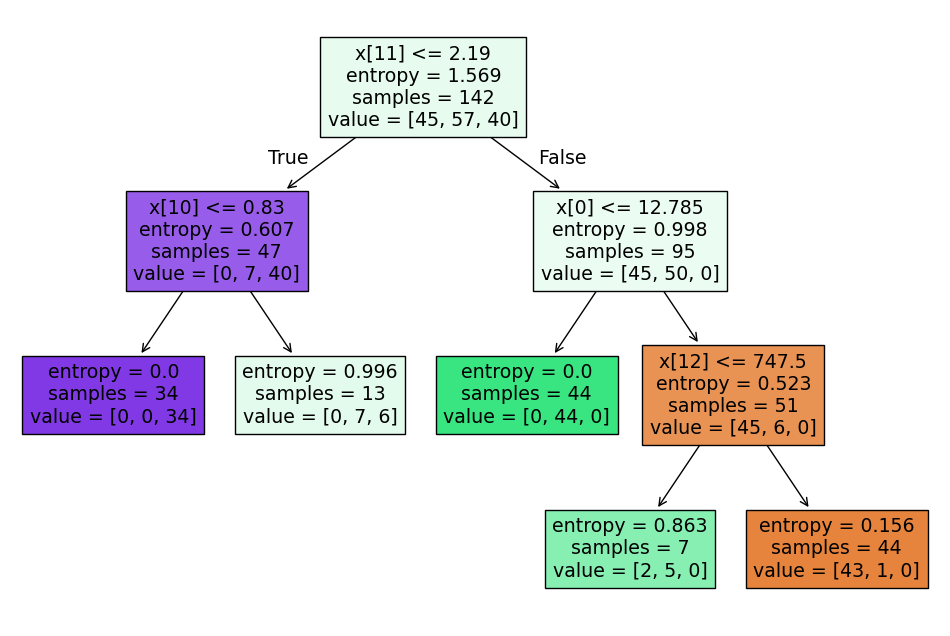

In [139]:
#visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.savefig("tree.png")
plt.show()